In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

sns.set_style("whitegrid")

In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

print("X Shape:", X.shape)
print("\nTarget Counts:")
print(y.value_counts())
print("\nStatistics:")
print(X.describe())

X Shape: (569, 30)

Target Counts:
target
1    357
0    212
Name: count, dtype: int64

Statistics:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.0

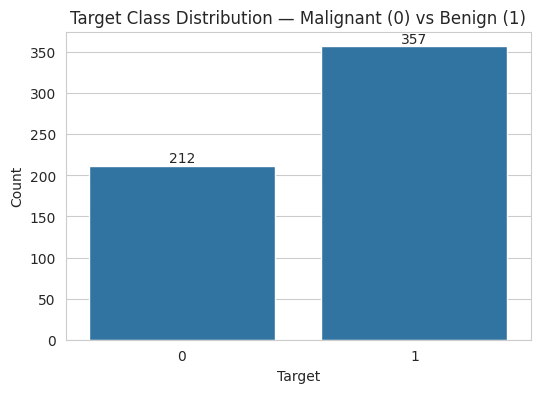

In [3]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x=y)
plt.title("Target Class Distribution — Malignant (0) vs Benign (1)")
plt.xlabel("Target")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Class Distribution

There is a mild class imbalance because there are 212 malignant cases and 357 benign cases.
However, the dataset is large enough for a binary classification task and stratified splitting
is used to preserve the class ratio.

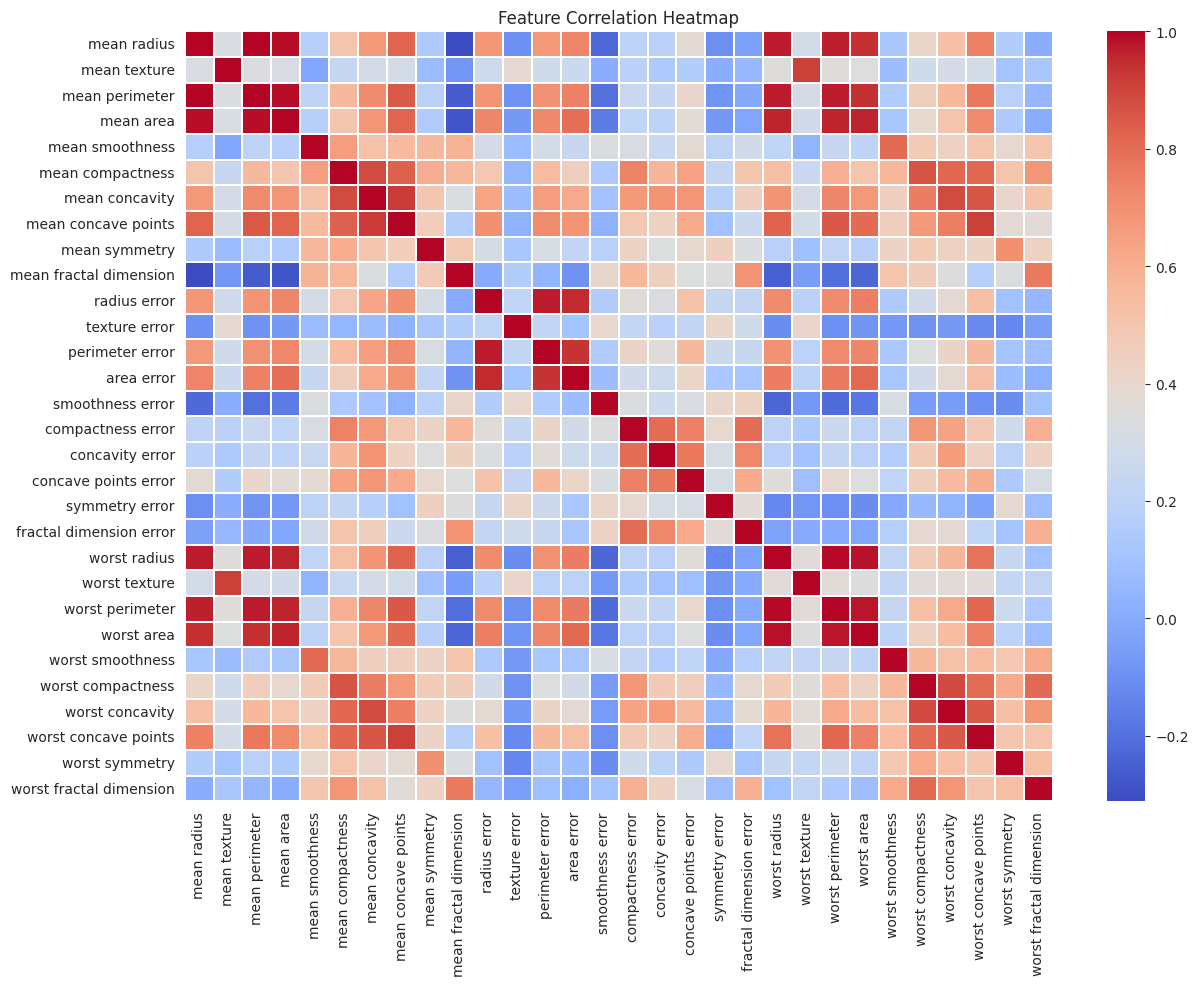

In [4]:
plt.figure(figsize=(14,10))
sns.heatmap(X.corr(), cmap="coolwarm", linewidths=0.3)
plt.title("Feature Correlation Heatmap")
plt.show()

### Feature Correlation

Some features such as radius_mean, perimeter_mean and area_mean are highly correlated.
High correlation is not a major problem for neural networks because neural networks can
learn useful combinations of features through their weights.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (455, 30)
X_test : (114, 30)
y_train: (455,)
y_test : (114,)


In [6]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Mean:", X_train_sc.mean(axis=0).round(2))
print("Std :", X_train_sc.std(axis=0).round(2))

Mean: [-0.  0. -0. -0.  0. -0. -0.  0. -0.  0. -0. -0.  0.  0. -0. -0.  0. -0.
  0.  0.  0. -0. -0.  0.  0. -0.  0. -0. -0.  0.]
Std : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


### Why Scaling?

Neural networks use gradient-based optimizers such as Adam.
If features have very different scales, large-valued features can dominate the learning process.

StandardScaler changes the features to approximately mean = 0 and standard deviation = 1.
The scaler is fitted only on training data to avoid data leakage.

In [7]:
model_slp = keras.Sequential([
    keras.layers.Dense(1, activation="sigmoid", input_shape=(30,))
])

model_slp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
model_slp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_slp = model_slp.fit(
    X_train_sc, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5697 - loss: 0.6866 - val_accuracy: 0.7391 - val_loss: 0.6805
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6601 - loss: 0.6077 - val_accuracy: 0.7609 - val_loss: 0.6173
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7311 - loss: 0.5442 - val_accuracy: 0.7826 - val_loss: 0.5630
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7971 - loss: 0.4889 - val_accuracy: 0.8043 - val_loss: 0.5193
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8435 - loss: 0.4461 - val_accuracy: 0.7826 - val_loss: 0.4821
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8631 - loss: 0.4105 - val_accuracy: 0.7826 - val_loss: 0.4510
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8753 - loss: 0.3810 - val_accuracy: 0.8043 - val_loss: 0.4250
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8875 - loss: 0.3562 - val_accuracy: 0.8043 - v

### Why Binary Crossentropy?

Binary crossentropy is suitable for binary classification.
The sigmoid output gives a probability between 0 and 1, and binary crossentropy
measures the difference between the predicted probability and the actual class.

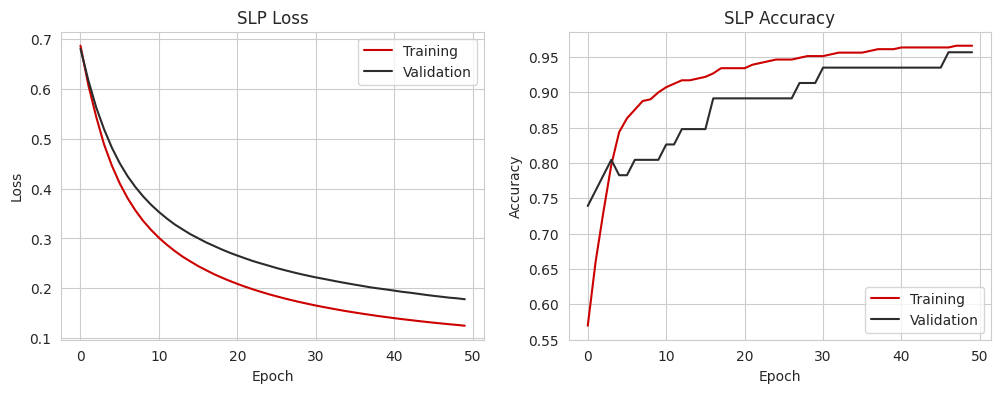

In [9]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_slp.history["loss"], color="#CC0000", label="Training")
plt.plot(history_slp.history["val_loss"], color="#2C2C2C", label="Validation")
plt.title("SLP Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_slp.history["accuracy"], color="#CC0000", label="Training")
plt.plot(history_slp.history["val_accuracy"], color="#2C2C2C", label="Validation")
plt.title("SLP Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [10]:
slp_loss, slp_acc = model_slp.evaluate(X_test_sc, y_test, verbose=0)

y_pred_slp = (model_slp.predict(X_test_sc, verbose=0) > 0.5).astype(int)

print("SLP Test Accuracy:", slp_acc)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_slp))

SLP Test Accuracy: 0.9122806787490845

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        42
           1       0.94      0.92      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114



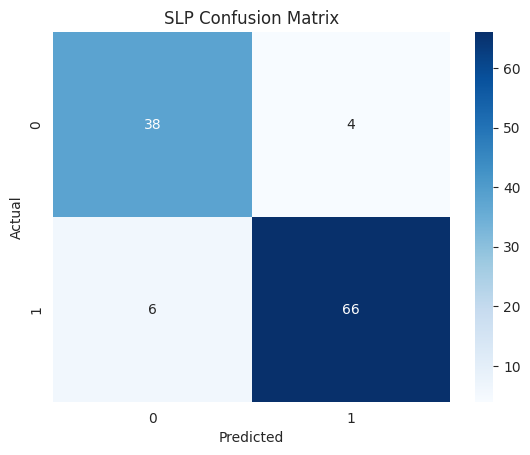

In [11]:
cm = confusion_matrix(y_test, y_pred_slp)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("SLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### SLP Limitation

A Single-Layer Perceptron can learn only a linear decision boundary.
The breast cancer dataset may contain complex relationships between features.
Therefore, an MLP with hidden layers can provide better representation and performance.

In [12]:
def make_mlp(activation):
    return keras.Sequential([
        keras.layers.Dense(64, activation=activation, input_shape=(30,)),
        keras.layers.Dense(32, activation=activation),
        keras.layers.Dense(1, activation="sigmoid")
    ])

model_mlp = make_mlp("relu")
model_mlp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
print("Manual parameters:")
print((30*64+64) + (64*32+32) + (32*1+1))

Manual parameters:
4097


In [14]:
model_mlp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_relu = model_mlp.fit(
    X_train_sc, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6650 - loss: 0.6155 - val_accuracy: 0.6957 - val_loss: 0.5596
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8851 - loss: 0.3688 - val_accuracy: 0.8913 - val_loss: 0.3877
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9315 - loss: 0.2474 - val_accuracy: 0.8913 - val_loss: 0.2886
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9511 - loss: 0.1791 - val_accuracy: 0.9130 - val_loss: 0.2284
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9633 - loss: 0.1409 - val_accuracy: 0.9348 - val_loss: 0.1889
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9731 - loss: 0.1154 - val_accuracy: 0.9348 - val_loss: 0.1560
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9731 - loss: 0.0994 - val_accuracy: 0.9565 - val_loss: 0.1317
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9780 - loss: 0.0875 - val_accuracy: 0.9565 - 

In [15]:
model_tanh = make_mlp("tanh")
model_sigmoid = make_mlp("sigmoid")

for model in [model_tanh, model_sigmoid]:
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

In [16]:
history_tanh = model_tanh.fit(
    X_train_sc, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

history_sigmoid = model_sigmoid.fit(
    X_train_sc, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

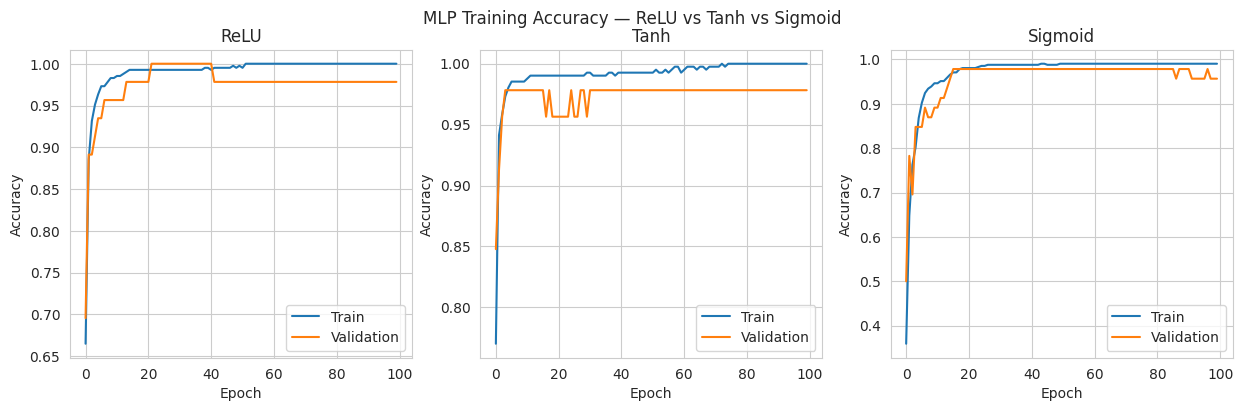

In [17]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.plot(history_relu.history["accuracy"], label="Train")
plt.plot(history_relu.history["val_accuracy"], label="Validation")
plt.title("ReLU")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,3,2)
plt.plot(history_tanh.history["accuracy"], label="Train")
plt.plot(history_tanh.history["val_accuracy"], label="Validation")
plt.title("Tanh")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,3,3)
plt.plot(history_sigmoid.history["accuracy"], label="Train")
plt.plot(history_sigmoid.history["val_accuracy"], label="Validation")
plt.title("Sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.suptitle("MLP Training Accuracy — ReLU vs Tanh vs Sigmoid")
plt.show()

### Activation Functions

**ReLU:** max(0, x). It usually converges quickly and reduces the vanishing gradient problem.

**Tanh:** produces values between -1 and 1 and is zero-centred, but can suffer from vanishing gradients.

**Sigmoid:** produces values between 0 and 1. It is useful in the output layer for binary classification,
but can suffer from vanishing gradients when used in hidden layers.

For this dataset, the model with the highest validation accuracy is considered the best activation model.

In [18]:
scores = {
    "ReLU": max(history_relu.history["val_accuracy"]),
    "Tanh": max(history_tanh.history["val_accuracy"]),
    "Sigmoid": max(history_sigmoid.history["val_accuracy"])
}

print(scores)

best_activation = max(scores, key=scores.get)
print("Best Activation:", best_activation)

{'ReLU': 1.0, 'Tanh': 0.97826087474823, 'Sigmoid': 0.97826087474823}
Best Activation: ReLU


In [19]:
models = {
    "ReLU": model_mlp,
    "Tanh": model_tanh,
    "Sigmoid": model_sigmoid
}

best_mlp = models[best_activation]

mlp_loss, mlp_acc = best_mlp.evaluate(X_test_sc, y_test, verbose=0)

y_pred_mlp = (best_mlp.predict(X_test_sc, verbose=0) > 0.5).astype(int)

print("Best MLP Accuracy:", mlp_acc)
print(classification_report(y_test, y_pred_mlp))

Best MLP Accuracy: 0.9561403393745422
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



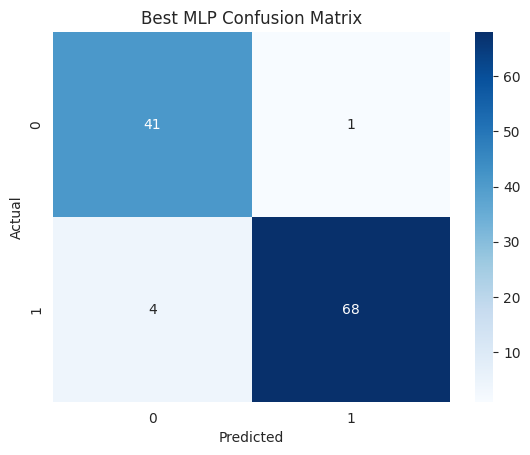

In [20]:
sns.heatmap(
    confusion_matrix(y_test, y_pred_mlp),
    annot=True, fmt="d", cmap="Blues"
)

plt.title("Best MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
model_es = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(30,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

model_es.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
es = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history_es = model_es.fit(
    X_train_sc, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8826 - loss: 0.4178 - val_accuracy: 0.9348 - val_loss: 0.2610
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9633 - loss: 0.1613 - val_accuracy: 0.9348 - val_loss: 0.1803
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9682 - loss: 0.1025 - val_accuracy: 0.9565 - val_loss: 0.1388
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9804 - loss: 0.0788 - val_accuracy: 0.9783 - val_loss: 0.1000
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9829 - loss: 0.0655 - val_accuracy: 0.9783 - val_loss: 0.0819
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9878 - loss: 0.0573 - val_accuracy: 0.9783 - val_loss: 0.0737
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9878 - loss: 0.0518 - val_accuracy: 0.9783 - val_loss: 0.0638
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9878 - loss: 0.0473 - val_accuracy: 0.

### Early Stopping

- **monitor='val_loss'**: monitors validation loss.
- **patience=15**: waits for 15 epochs without improvement.
- **restore_best_weights=True**: restores the weights from the best epoch.
- **verbose=1**: displays when training stops.

Early Stopping helps prevent overfitting.

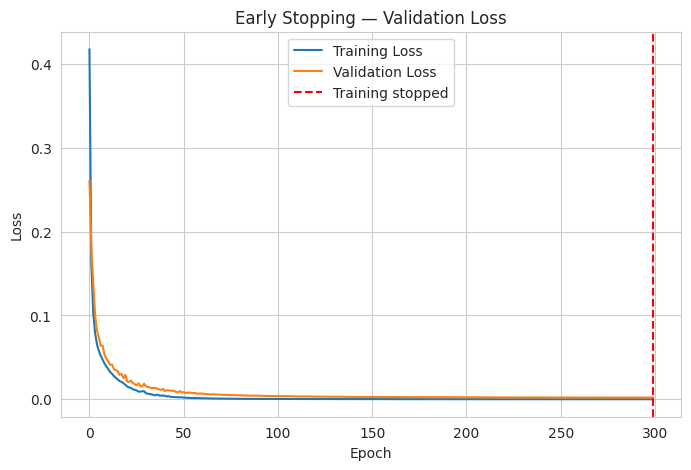

In [23]:
stop_epoch = len(history_es.history["loss"])

plt.figure(figsize=(8,5))
plt.plot(history_es.history["loss"], label="Training Loss")
plt.plot(history_es.history["val_loss"], label="Validation Loss")
plt.axvline(stop_epoch-1, color="red", linestyle="--",
            label="Training stopped")
plt.title("Early Stopping — Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [24]:
model_no_es = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(30,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

model_no_es.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_no_es = model_no_es.fit(
    X_train_sc, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

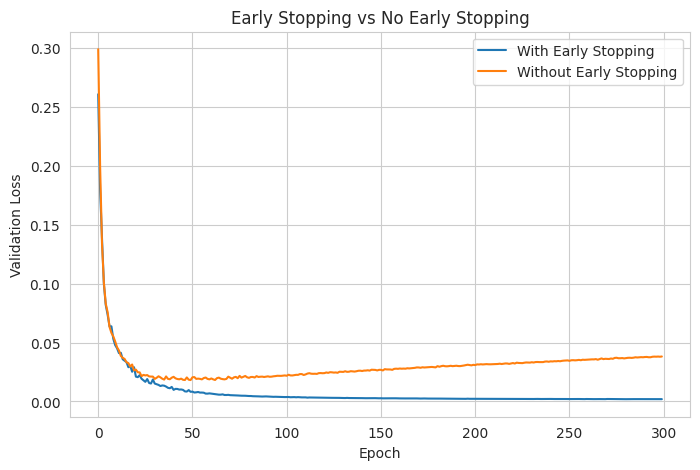

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history_es.history["val_loss"], label="With Early Stopping")
plt.plot(history_no_es.history["val_loss"], label="Without Early Stopping")

plt.title("Early Stopping vs No Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

In [26]:
es_acc = model_es.evaluate(X_test_sc, y_test, verbose=0)[1]
no_es_acc = model_no_es.evaluate(X_test_sc, y_test, verbose=0)[1]

print("Early Stopping Accuracy:", es_acc)
print("Without Early Stopping Accuracy:", no_es_acc)

Early Stopping Accuracy: 0.9649122953414917
Without Early Stopping Accuracy: 0.9649122953414917


In [27]:
def make_dropout(rate):
    return keras.Sequential([
        keras.layers.Dense(128, activation="relu", input_shape=(30,)),
        keras.layers.Dropout(rate),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(rate),
        keras.layers.Dense(1, activation="sigmoid")
    ])

In [28]:
model_drop = make_dropout(0.3)

model_drop.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

es_drop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_drop = model_drop.fit(
    X_train_sc, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_drop],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.7335 - loss: 0.5520 - val_accuracy: 0.9348 - val_loss: 0.3571
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9413 - loss: 0.2658 - val_accuracy: 0.9348 - val_loss: 0.2325
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9511 - loss: 0.1626 - val_accuracy: 0.9348 - val_loss: 0.1823
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9584 - loss: 0.1199 - val_accuracy: 0.9565 - val_loss: 0.1505
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9609 - loss: 0.1012 - val_accuracy: 0.9565 - val_loss: 0.1172
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9780 - loss: 0.0815 - val_accuracy: 0.9565 - val_loss: 0.0983
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9829 - loss: 0.0741 - val_accuracy: 0.9565 - val_loss: 0.0838
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9829 - loss: 0.0687 - val_accuracy: 0.

### Dropout

Dropout randomly turns off a percentage of neurons during training.
With Dropout(0.3), approximately 30% of activations are ignored during each training batch.

This prevents the network from depending too much on particular neurons and can reduce overfitting.
During prediction, dropout is automatically disabled.

In [29]:
drop_models = {}
drop_histories = {}

for rate in [0.1, 0.3, 0.5]:
    model = make_dropout(rate)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train_sc, y_train,
        epochs=200,
        batch_size=32,
        validation_split=0.1,
        callbacks=[EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True
        )],
        verbose=0
    )

    drop_models[rate] = model
    drop_histories[rate] = history

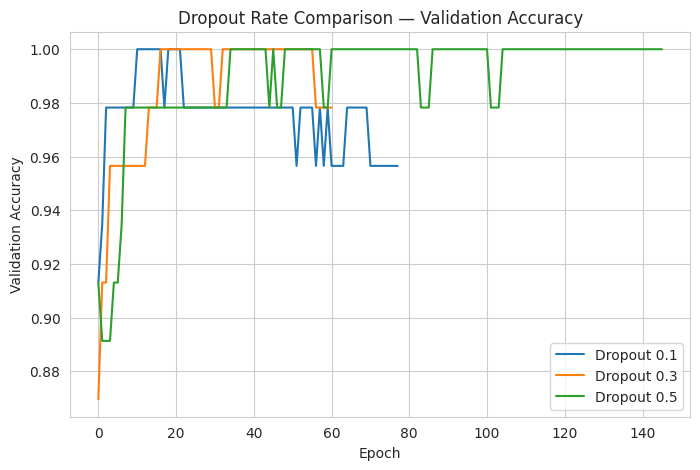

In [30]:
plt.figure(figsize=(8,5))

for rate in [0.1, 0.3, 0.5]:
    plt.plot(
        drop_histories[rate].history["val_accuracy"],
        label=f"Dropout {rate}"
    )

plt.title("Dropout Rate Comparison — Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

In [31]:
drop_scores = {
    rate: max(drop_histories[rate].history["val_accuracy"])
    for rate in [0.1, 0.3, 0.5]
}

print(drop_scores)

best_drop_rate = max(drop_scores, key=drop_scores.get)
best_drop = drop_models[best_drop_rate]

print("Best Dropout Rate:", best_drop_rate)

{0.1: 1.0, 0.3: 1.0, 0.5: 1.0}
Best Dropout Rate: 0.1


In [32]:
drop_acc = best_drop.evaluate(X_test_sc, y_test, verbose=0)[1]

y_pred_drop = (best_drop.predict(X_test_sc, verbose=0) > 0.5).astype(int)

print("Dropout Test Accuracy:", drop_acc)
print(classification_report(y_test, y_pred_drop))

Dropout Test Accuracy: 0.9561403393745422
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



### Dropout Rate

A low dropout rate such as 0.1 may not provide enough regularization.
A high rate such as 0.5 may remove too many neurons and cause underfitting.
Therefore, the best rate is selected using validation accuracy.

In [33]:
def make_regularized(reg):
    return keras.Sequential([
        keras.layers.Dense(
            128, activation="relu",
            input_shape=(30,),
            kernel_regularizer=reg
        ),
        keras.layers.Dense(
            64, activation="relu",
            kernel_regularizer=reg
        ),
        keras.layers.Dense(1, activation="sigmoid")
    ])

In [34]:
model_l2 = make_regularized(regularizers.l2(0.001))

model_l2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_l2 = model_l2.fit(
    X_train_sc, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )],
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model_l1 = make_regularized(regularizers.l1(0.001))

model_l1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_l1 = model_l1.fit(
    X_train_sc, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )],
    verbose=0
)

In [36]:
model_l1l2 = make_regularized(
    regularizers.l1_l2(l1=0.0001, l2=0.001)
)

model_l1l2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_l1l2 = model_l1l2.fit(
    X_train_sc, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )],
    verbose=0
)

### Regularization

**L1:** adds a penalty based on the absolute values of weights. It can make some weights exactly zero,
which can perform feature selection.

**L2:** penalizes large weights using squared values. It encourages smaller and smoother weights
and helps reduce overfitting.

**L1-L2:** combines both L1 and L2 regularization. It is also called ElasticNet regularization.

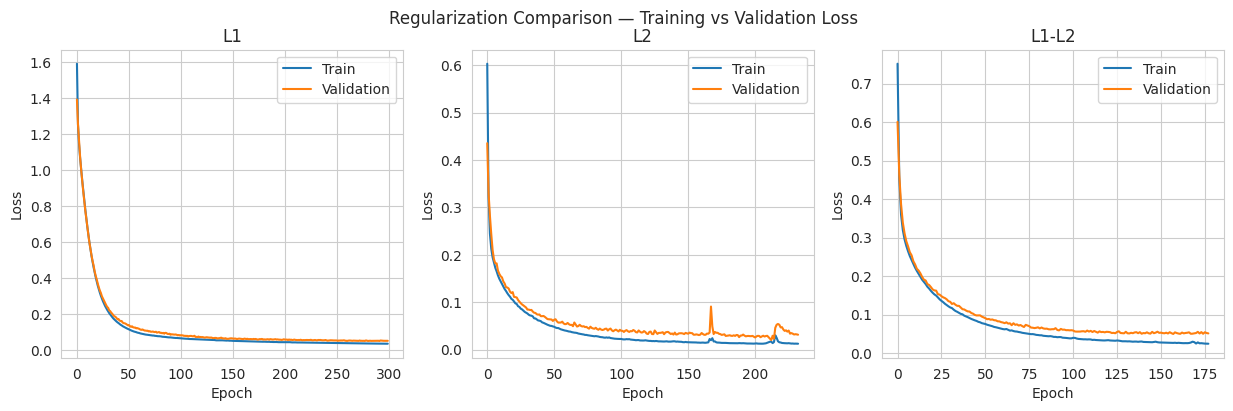

In [37]:
histories = {
    "L1": history_l1,
    "L2": history_l2,
    "L1-L2": history_l1l2
}

plt.figure(figsize=(15,4))

for i, name in enumerate(histories):
    h = histories[name]

    plt.subplot(1,3,i+1)
    plt.plot(h.history["loss"], label="Train")
    plt.plot(h.history["val_loss"], label="Validation")
    plt.title(name)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

plt.suptitle("Regularization Comparison — Training vs Validation Loss")
plt.show()

In [38]:
reg_models = {
    "L1": model_l1,
    "L2": model_l2,
    "L1-L2": model_l1l2
}

reg_acc = {}

for name, model in reg_models.items():
    reg_acc[name] = model.evaluate(X_test_sc, y_test, verbose=0)[1]

print(reg_acc)

{'L1': 0.9649122953414917, 'L2': 0.9561403393745422, 'L1-L2': 0.9561403393745422}


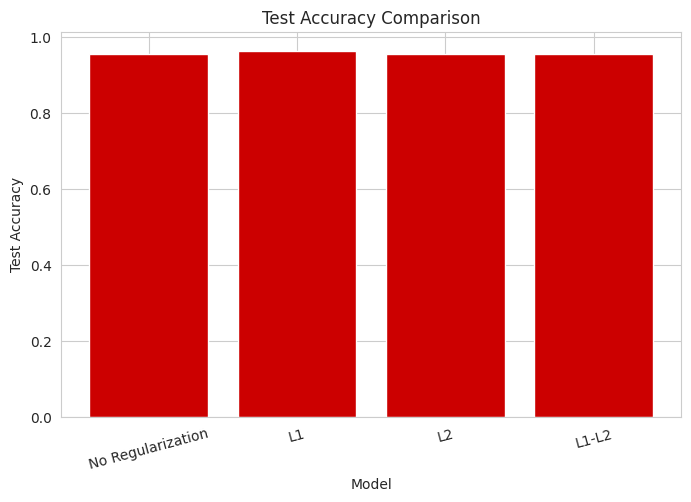

In [39]:
names = ["No Regularization", "L1", "L2", "L1-L2"]
values = [
    mlp_acc,
    reg_acc["L1"],
    reg_acc["L2"],
    reg_acc["L1-L2"]
]

plt.figure(figsize=(8,5))
plt.bar(names, values, color="#CC0000")
plt.title("Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=15)
plt.show()

In [40]:
model_final = keras.Sequential([
    keras.layers.Dense(
        128, activation="relu",
        input_shape=(30,),
        kernel_regularizer=regularizers.l2(0.001)
    ),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(
        64, activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(1, activation="sigmoid")
])

model_final.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_final.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
es_final = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_final = model_final.fit(
    X_train_sc, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_final],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8093 - loss: 0.6387 - val_accuracy: 0.8913 - val_loss: 0.4853
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9389 - loss: 0.3758 - val_accuracy: 0.8913 - val_loss: 0.3598
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9560 - loss: 0.2814 - val_accuracy: 0.8913 - val_loss: 0.3044
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9682 - loss: 0.2348 - val_accuracy: 0.9565 - val_loss: 0.2642
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9780 - loss: 0.2121 - val_accuracy: 0.9783 - val_loss: 0.2358
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9756 - loss: 0.2077 - val_accuracy: 0.9565 - val_loss: 0.2242
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9804 - loss: 0.1983 - val_accuracy: 0.9565 - val_loss: 0.2119
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9878 - loss: 0.1882 - val_accuracy: 0.

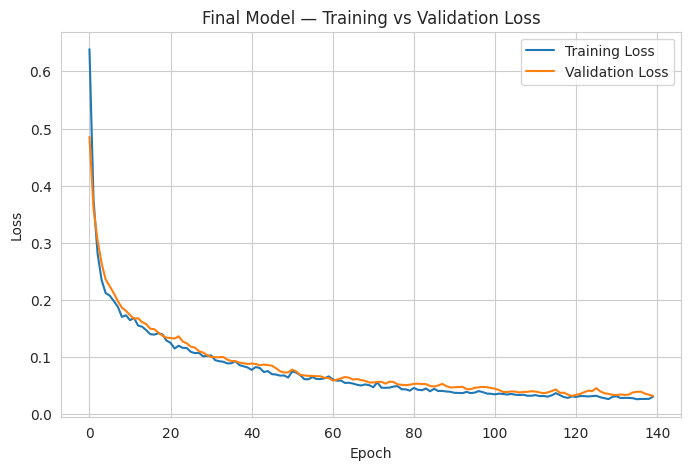

In [42]:
plt.figure(figsize=(8,5))

plt.plot(history_final.history["loss"], label="Training Loss")
plt.plot(history_final.history["val_loss"], label="Validation Loss")

plt.title("Final Model — Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [43]:
def get_metrics(model):
    loss, acc = model.evaluate(X_test_sc, y_test, verbose=0)
    pred = (model.predict(X_test_sc, verbose=0) > 0.5).astype(int)

    report = classification_report(
        y_test, pred, output_dict=True
    )

    return [
        acc,
        report["1"]["precision"],
        report["1"]["recall"],
        report["1"]["f1-score"]
    ]

In [44]:
results = []

model_list = [
    ("SLP", "30-1", "None", 0, "No", model_slp),
    ("MLP-ReLU", "30-64-32-1", "None", 0, "No", model_mlp),
    ("MLP + Early Stopping", "30-128-64-1", "None", 0, "Yes", model_es),
    ("MLP + Dropout", "30-128-64-1", "None", best_drop_rate, "Yes", best_drop),
    ("MLP + L2", "30-128-64-1", "L2", 0, "Yes", model_l2),
    ("Final Combined", "30-128-64-1", "L2", 0.3, "Yes", model_final)
]

for name, arch, reg, drop, early, model in model_list:
    acc, precision, recall, f1 = get_metrics(model)

    results.append([
        name, arch, reg, drop, early,
        acc, precision, recall, f1
    ])

results_df = pd.DataFrame(results, columns=[
    "Model",
    "Architecture",
    "Regularization",
    "Dropout Rate",
    "Early Stopping",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1-Score"
])

results_df

,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP,30-1,None,0.0,No,0.912281,0.942857,0.916667,0.929577
1,MLP-ReLU,30-64-32-1,None,0.0,No,0.956140,0.985507,0.944444,0.964539
2,MLP + Early Stopping,30-128-64-1,None,0.0,Yes,0.964912,0.985714,0.958333,0.971831
3,MLP + Dropout,30-128-64-1,None,0.1,Yes,0.956140,0.985507,0.944444,0.964539
4,MLP + L2,30-128-64-1,L2,0.0,Yes,0.956140,0.985507,0.944444,0.964539
5,Final Combined,30-128-64-1,L2,0.3,Yes,0.956140,0.985507,0.944444,0.964539


In [49]:
results_df.style.highlight_max(
    subset=["Test Accuracy", "Test F1-Score"],
    color="#ffcccc"
)

,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP,30-1,None,0.000000,No,0.912281,0.942857,0.916667,0.929577
1,MLP-ReLU,30-64-32-1,None,0.000000,No,0.956140,0.985507,0.944444,0.964539
2,MLP + Early Stopping,30-128-64-1,None,0.000000,Yes,0.964912,0.985714,0.958333,0.971831
3,MLP + Dropout,30-128-64-1,None,0.100000,Yes,0.956140,0.985507,0.944444,0.964539
4,MLP + L2,30-128-64-1,L2,0.000000,Yes,0.956140,0.985507,0.944444,0.964539
5,Final Combined,30-128-64-1,L2,0.300000,Yes,0.956140,0.985507,0.944444,0.964539


In [50]:
y_pred_final = (
    model_final.predict(X_test_sc, verbose=0) > 0.5
).astype(int)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



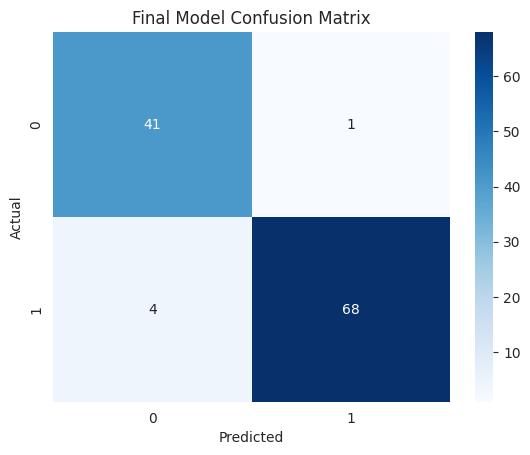

In [51]:
sns.heatmap(
    confusion_matrix(y_test, y_pred_final),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Clinical Insights



## Clinical Insight for Medical Diagnosis Support

The final model combines L2 regularization, Dropout and Early Stopping.
These techniques help reduce overfitting and improve generalisation.

For cancer diagnosis, recall is very important because a false negative means
a malignant case may be classified as benign.

Therefore, when selecting a model for clinical decision support, we should consider
both recall and precision instead of accuracy alone.

The default classification threshold is 0.5. In a real clinical application,
a lower threshold could be considered to improve sensitivity and reduce false negatives.
However, the threshold should be selected using clinical validation and should not
be decided only from this small educational dataset.

Among Early Stopping, Dropout and Regularization, the technique that produces
the best validation/test generalisation in this experiment should be considered
the most useful for this dataset.

## Conclusion

In this project, the Breast Cancer Wisconsin dataset was used for binary classification.

First, the data was explored and StandardScaler was applied.
A Single-Layer Perceptron was used as a baseline model.

Then, an MLP with hidden layers was created and ReLU, Tanh and Sigmoid activation
functions were compared.

Early Stopping was used to reduce overfitting.
Dropout was then tested with different dropout rates.
L1, L2 and L1-L2 regularization were also compared.

Finally, a combined model using L2 regularization, Dropout and Early Stopping
was trained.

The final results table shows the performance of the different models using
Accuracy, Precision, Recall and F1-Score.